In [ ]:
!pip install pandas scikit-learn matplotlib pylatexenc seaborn rdkit

#**Classical**

Preparing BBBP Dataset...


Extracting Morgan Fingerprints...


Running 10-Split Evaluation...



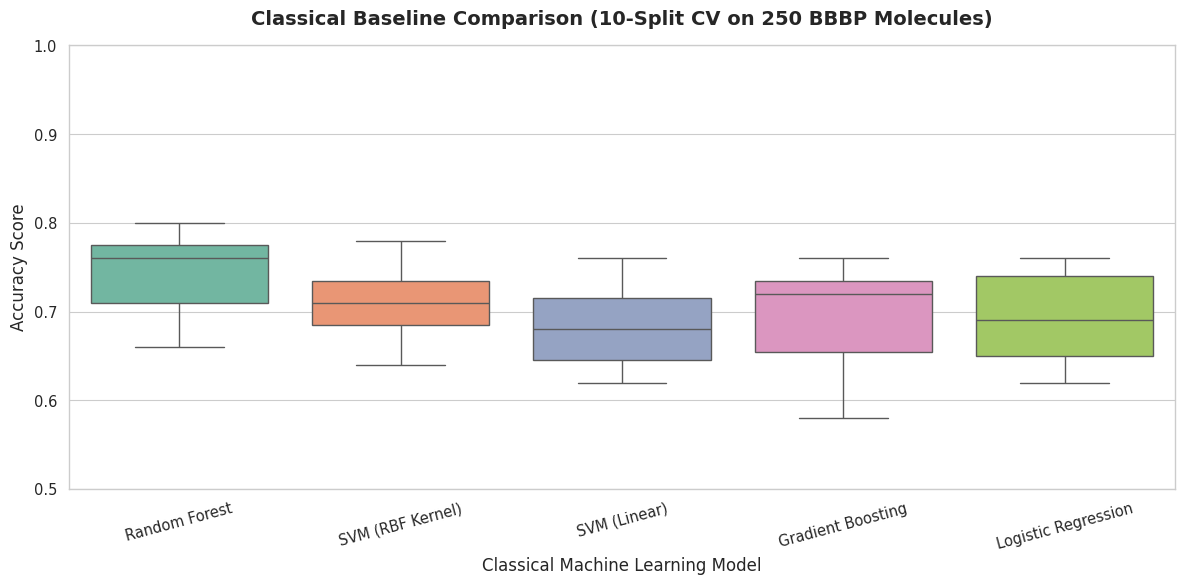

Classical Model        | Accuracy      | Precision     | Recall        | F1-Score      | AUC-ROC      
---------------------------------------------------------------------------------------------------------
Random Forest          | 0.742 ± 0.052 | 0.743 ± 0.044 | 0.740 ± 0.102 | 0.739 ± 0.065 | 0.801 ± 0.056
SVM (RBF Kernel)       | 0.710 ± 0.043 | 0.712 ± 0.049 | 0.712 ± 0.101 | 0.708 ± 0.055 | 0.797 ± 0.048
Gradient Boosting      | 0.692 ± 0.063 | 0.691 ± 0.062 | 0.696 ± 0.097 | 0.692 ± 0.070 | 0.748 ± 0.067
Logistic Regression    | 0.692 ± 0.053 | 0.694 ± 0.052 | 0.692 ± 0.103 | 0.689 ± 0.063 | 0.760 ± 0.033
SVM (Linear)           | 0.682 ± 0.045 | 0.696 ± 0.049 | 0.652 ± 0.103 | 0.669 ± 0.062 | 0.740 ± 0.037


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Classical Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')

# --- 1. DATA PREPARATION ---
print("Preparing BBBP Dataset...")
df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv")
df = df.dropna(subset=['p_np', 'smiles'])
df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None and len(s) < 70)]

n_sub = 125
df_final = pd.concat([
    df[df['p_np']==1].sample(n_sub, random_state=42),
    df[df['p_np']==0].sample(n_sub, random_state=42)
]).sample(frac=1, random_state=42)

y = df_final['p_np'].values
smiles_list = df_final['smiles'].values

# Extract Classical Features (256-bit Morgan Fingerprints)
print("Extracting Morgan Fingerprints...")
X_class = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=256)) for s in smiles_list])

# --- 2. DEFINE MODELS TO TEST ---
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=10, probability=True, random_state=42), # exact with Quantum
    "SVM (Linear)": SVC(kernel='linear', C=1, probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# --- 3. 10-SPLIT CROSS VALIDATION ---
print("Running 10-Split Evaluation...\n")
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
results_list = []

for i, (train_idx, test_idx) in enumerate(sss.split(X_class, y)):
    y_test = y[test_idx]

    # Scale data (Critical for SVM and Logistic Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_class[train_idx])
    X_test_scaled = scaler.transform(X_class[test_idx])

    for model_name, clf in models.items():
        # Fit the model
        clf.fit(X_train_scaled, y[train_idx])

        # Predict
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]

        # Store Metrics
        results_list.append({
            'Split': i,
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0),
            'AUC-ROC': roc_auc_score(y_test, y_prob)
        })

# --- 4. VISUALIZATION & OUTPUT ---
df_plot = pd.DataFrame(results_list)

# Boxplot to show accuracy spread
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.boxplot(data=df_plot, x='Model', y='Accuracy', palette='Set2')
plt.title('Classical Baseline Comparison (10-Split CV on 250 BBBP Molecules)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classical Machine Learning Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


print("="*105)
print(f"{'Classical Model':22} | {'Accuracy':13} | {'Precision':13} | {'Recall':13} | {'F1-Score':13} | {'AUC-ROC':13}")
print("-" * 105)

# Calculate means and std devs, sorted by highest accuracy
agg_df = df_plot.groupby('Model').agg(['mean', 'std'])['Accuracy'].sort_values(by='mean', ascending=False)

for model in agg_df.index:
    subset = df_plot[df_plot['Model'] == model]
    acc_str = f"{subset['Accuracy'].mean():.3f} ± {subset['Accuracy'].std():.3f}"
    prec_str = f"{subset['Precision'].mean():.3f} ± {subset['Precision'].std():.3f}"
    rec_str = f"{subset['Recall'].mean():.3f} ± {subset['Recall'].std():.3f}"
    f1_str = f"{subset['F1-Score'].mean():.3f} ± {subset['F1-Score'].std():.3f}"
    auc_str = f"{subset['AUC-ROC'].mean():.3f} ± {subset['AUC-ROC'].std():.3f}"
    print(f"{model:22} | {acc_str:13} | {prec_str:13} | {rec_str:13} | {f1_str:13} | {auc_str:13}")
print("=" * 105)